v2: clean v1 and comparison with deblender

Test are done with sample up to 24.5 magnitude

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import backend as K
from sklearn import preprocessing
from importlib import reload
import matplotlib as mpl
import scipy
import matplotlib

sys.path.insert(0,'../../scripts/tools_for_VAE/')
from tools_for_VAE import utils, vae_functions, generator, model, boxplot, plot

%matplotlib inline
%config InlineBackend.figure_format='retina'

W0626 23:52:51.399812 140448743356224 deprecation.py:323] From /sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/tensorflow_core/python/compat/v2_compat.py:88: disable_resource_variables (from tensorflow.python.ops.variable_scope) is deprecated and will be removed in a future version.
Instructions for updating:
non-resource variables are not supported in the long term


## Load transformations of ellipticities

In [2]:
## Compute lensed ellipticities from shear and 
def calc_lensed_ellipticity_1(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =  es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.real(e)

def calc_lensed_ellipticity_2(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =   es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.imag(e)

def calc_lensed_ellipticity(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =   es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.absolute(e)

ellipticity_conversion = lambda e: 2*e / (1.0+ellipticity[:len(e)]*ellipticity[:len(e)])

# Load models

## Loading directories

In [3]:
root_dir_models = '/sps/lsst/users/barcelin/TFP/weights/test_dc2/'
dir_model_v1 = root_dir_models+'v_no_psf_redshift_ellipticity_no_weights/loss/'# Deterministic network

## Set models parameters

In [4]:
######## Parameters
nb_of_bands = 6
batch_size = 128

input_shape = (59, 59, nb_of_bands)
hidden_dim = 256
latent_dim = 32
final_dim = 3
filters = [32,64,128,256]
kernels = [3,3,3,3]

conv_activation = None
dense_activation = None

bands = [0,1,2,3,4,5]

## Define and load models

In [5]:
model = model.create_model_wo_ls_peak_pooling_no_psf(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation=None, dense_activation=None)

W0626 23:52:57.698395 140448743356224 deprecation.py:506] From /sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/tensorflow_core/python/ops/resource_variable_ops.py:1635: calling BaseResourceVariable.__init__ (from tensorflow.python.ops.resource_variable_ops) with constraint is deprecated and will be removed in a future version.
Instructions for updating:
If using Keras pass *_constraint arguments to layers.
W0626 23:52:58.265401 140448743356224 deprecation.py:506] From /sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/tensorflow_core/python/ops/linalg/linear_operator_lower_triangular.py:158: calling LinearOperator.__init__ (from tensorflow.python.ops.linalg.linear_operator) with graph_parents is deprecated and will be removed in a future version.
Instructions for updating:
Do not pass `graph_parents`.  They will  no longer be used.


In [6]:
latest = tf.train.latest_checkpoint(dir_model_v1)
model.load_weights(latest)

# Load data 

In [7]:
root_dir_v1 = '/pbs/home/b/barcelin/sps_link/data/dc2_test/24.5/test/' # mag cut at 24.5 in r band

images = np.load(root_dir_v1+'img_cropped_sample_2.npy', mmap_mode = 'c')
psf = np.load(root_dir_v1+'psf_cropped_sample_2.npy', mmap_mode = 'c')
data = pd.read_csv(root_dir_v1+'img_noiseless_data_2.csv')

#data.replace([np.inf, -np.inf], np.nan, inplace=True)
#data = data.dropna(axis = 0, how = 'any')

#new_data=data[(np.abs(data['e1_hsm_regauss'])<=1.) & (np.abs(data['e2_hsm_regauss'])<=1.) & (data['blendedness']>0)]

ell_1 = np.array(data['e1'])
ell_2 = np.array(data['e2'])
shear_1 = np.array(data['shear_1'])
shear_2 = np.array(data['shear_2'])
convergence = np.array(data['convergence'])


ellipticity = calc_lensed_ellipticity(-ell_1, ell_2, -shear_1, shear_2, convergence)
ellipticity_conversion = lambda e: 2*e / (1.0+ellipticity[:len(e)]*ellipticity[:len(e)])

e1 = ellipticity_conversion(calc_lensed_ellipticity_1(-ell_1, ell_2, -shear_1, shear_2, convergence))
e2 = ellipticity_conversion(calc_lensed_ellipticity_2(-ell_1, ell_2, -shear_1, shear_2, convergence))

data['e1_lensed'] = e1
data['e2_lensed'] = e2

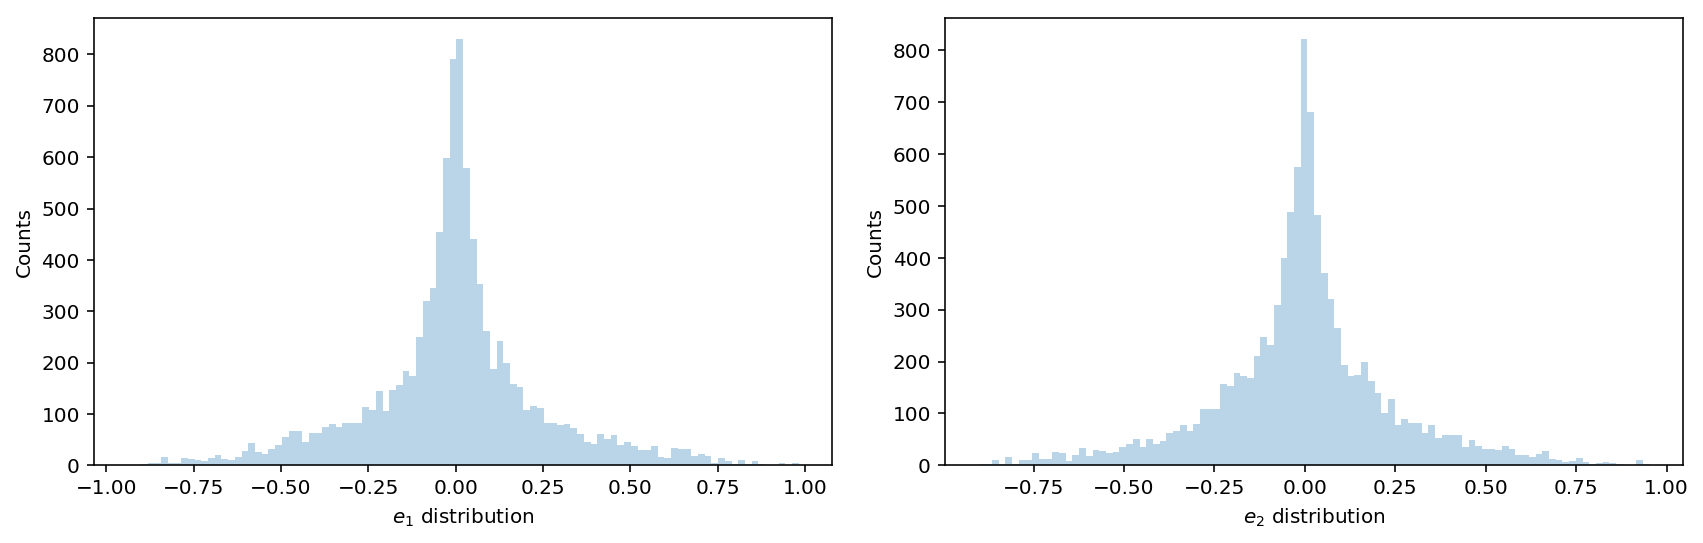

In [8]:
fig, axes = plt.subplots(1,2, figsize =(12,4))
font = {'family' : 'normal',
        'size'   : 12}

matplotlib.rc('font', **font)

_ = axes[0].hist(data['e1_lensed'], bins = 100, alpha = 0.3, label = '$e_1$')
_ = axes[1].hist(data['e2_lensed'], bins = 100, alpha = 0.3, label = '$e_2$')
axes[0].set_xlabel('$e_1$ distribution')
axes[1].set_xlabel('$e_2$ distribution')
axes[0].set_ylabel('Counts')
axes[1].set_ylabel('Counts')
#axes.errorbar(np.array([1000,500,200,100,50,40,30,20,10,5,3,2]),np.array(mean_error),yerr=np.array(std_error), fmt='.', label = 'on subset of test sample', alpha = 0.5)
#axes.set_xscale('log')
#axes.set_xlabel('Number of examples')
#axes.set_ylabel('Error in ellipticity $\Delta |e|$')
#axes.set_ylim(-0.1,0.12)
#axes.axhline(np.mean(df['e_error_reg'][:10000]), color = 'orange', alpha = 0.3, label = 'on complete test sample')
#axes.legend()
plt.tight_layout()

#fig.savefig('imgs/ellipticity_distrib.pdf')

# Test of models

## Deterministic model

### Perform test

In [10]:
output_v1 = model([tf.cast(images[9000:10000], tf.float32), tf.cast(psf[9000:10000], tf.float32)])

mean = K.get_value(output_v1.mean())
std = K.get_value(output_v1.stddev())

e1_out_mean = mean[:,0]
e2_out_mean = mean[:,1]

e1_out_std = std[:,0]
e2_out_std = std[:,1]

z_out_mean = mean[:,2]
z_out_std = std[:,2]

In [11]:
df = pd.DataFrame()

df['e1_out_mean'] = e1_out_mean
df['e2_out_mean'] = e2_out_mean
df['e1_out_std'] = e1_out_std
df['e2_out_std'] = e2_out_std
df['z_out_mean'] = z_out_mean
df['z_out_std'] = z_out_std

df.to_csv('data/df_param_ell_redshift_4_2.csv')

In [14]:
part_1 = pd.read_csv('data/df_param_ell_redshift_1_2.csv', encoding = 'utf-8')
part_2 = pd.read_csv('data/df_param_ell_redshift_2_2.csv', encoding = 'utf-8')
part_3 = pd.read_csv('data/df_param_ell_redshift_3_2.csv', encoding = 'utf-8')
part_4 = pd.read_csv('data/df_param_ell_redshift_4_2.csv', encoding = 'utf-8')

df_plot = pd.concat([part_1,part_2, part_3, part_4], ignore_index = True)

### Plots

In [15]:
df = pd.DataFrame()

d = pd.DataFrame()
d['e1'] = df_plot['e1_out_mean']
d['e2'] = df_plot['e2_out_mean']
d['e1_std'] = df_plot['e1_out_std']
d['e2_std'] = df_plot['e2_out_std']
d['e1_in'] = -e1
d['e2_in'] = e2
d['e_in'] = np.sqrt(d['e1_in']**2+d['e2_in']**2)

df['z_in']=pd.concat([data['redshift'],data['redshift']], ignore_index = True)
df['z_out']=pd.concat([df_plot['z_out_mean'],df_plot['z_out_mean']], ignore_index = True)
df['e_1'] = pd.concat([d['e1'],data['e1_hsm_regauss']], ignore_index = True)#, ignore_index=True, sort = True)
df['e_2'] = pd.concat([d['e2'],data['e2_hsm_regauss']], ignore_index = True)
df['e'] = pd.concat([np.sqrt(d['e1']**2+d['e2']**2),np.sqrt(data['e1_hsm_regauss']**2+data['e2_hsm_regauss']**2)], ignore_index = True)
df['e_in'] = pd.concat([d['e_in'],d['e_in']], ignore_index = True)
df['e_error_reg'] = df['e']-df['e_in']
#df['e_1_hsm'] = data['e1_hsm_regauss'][indices]
#df['e_2_hsm'] = data['e2_hsm_regauss'][indices]
#df['e_hsm'] = np.sqrt(df['e_1_hsm']**2+df['e_2_hsm']**2)

df['blendedness'] = pd.concat([data['blendedness'],data['blendedness']], ignore_index = True)
df['snr_r'] = pd.concat([data['snr_r'],data['snr_r']], ignore_index = True)

df['exp'] = [1]*10000+[2]*10000

In [16]:
df_plot_2 = df[df['blendedness']>0]

In [17]:
import numpy as np
import scipy.stats as stats
import math

mu = 0
variance = 1
sigma = math.sqrt(variance)
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
#plt.plot(x, stats.norm.pdf(x, mu, sigma))
#plt.show()

/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6521: MatplotlibDeprecationWarning: 
The 'normed' kwarg was deprecated in Matplotlib 2.1 and will be removed in 3.1. Use 'density' instead.
  alternative="'density'", removal="3.1")


(-7, 7)

/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/matplotlib/font_manager.py:1241: UserWarning: findfont: Font family ['normal'] not found. Falling back to DejaVu Sans.
  (prop.get_family(), self.defaultFamily[fontext]))


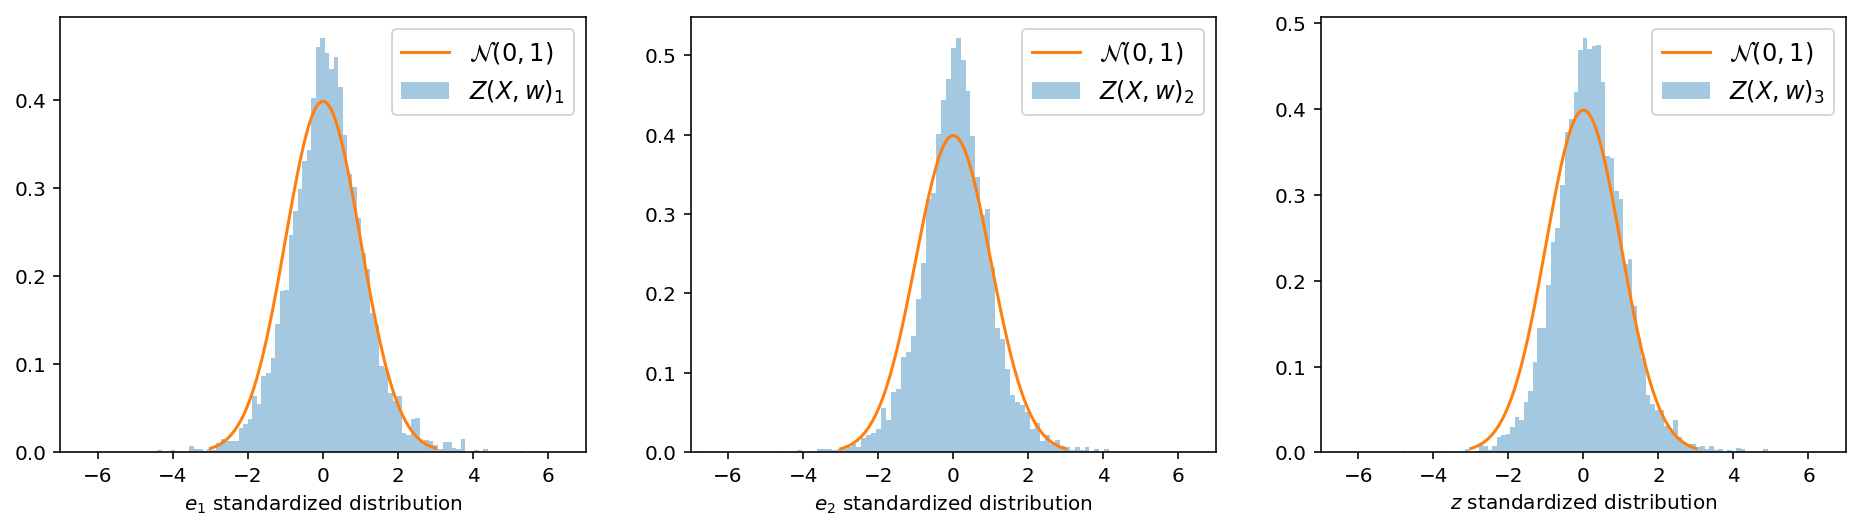

In [18]:
fig, axes = plt.subplots(1,3, figsize =(16,4))
font = {'family' : 'normal',
        'size'   : 12}

matplotlib.rc('font', **font)


_ = axes[0].hist((d['e1_in']-d['e1'])/d['e1_std'], bins = 100, normed = True, alpha = 0.4, label='$Z(X,w)_1$')
axes[0].plot(x, stats.norm.pdf(x, mu, sigma),label = '$\mathcal{N}(0,1)$')
axes[0].set_xlabel('$e_1$ standardized distribution')
axes[0].legend()
axes[0].set_xlim(-7,7)


_ = axes[1].hist((d['e2_in']-d['e2'])/d['e1_std'], bins = 100, normed = True, alpha = 0.4, label='$Z(X,w)_2$')
axes[1].plot(x, stats.norm.pdf(x, mu, sigma), label = '$\mathcal{N}(0,1)$')
axes[1].set_xlabel('$e_2$ standardized distribution')
axes[1].legend()
axes[1].set_xlim(-7,7)

_ = axes[2].hist((data['redshift']-df_plot['z_out_mean'])/df_plot['z_out_std'], bins = 100, normed = True, alpha = 0.4, label='$Z(X,w)_3$')
axes[2].plot(x, stats.norm.pdf(x, mu, sigma), label = '$\mathcal{N}(0,1)$')
axes[2].set_xlabel('$z$ standardized distribution')
axes[2].legend()
axes[2].set_xlim(-7,7)

#fig.savefig('imgs/distrib_al_param_ell_redshift.pdf')

16170
[1 2]
0 1
1 2


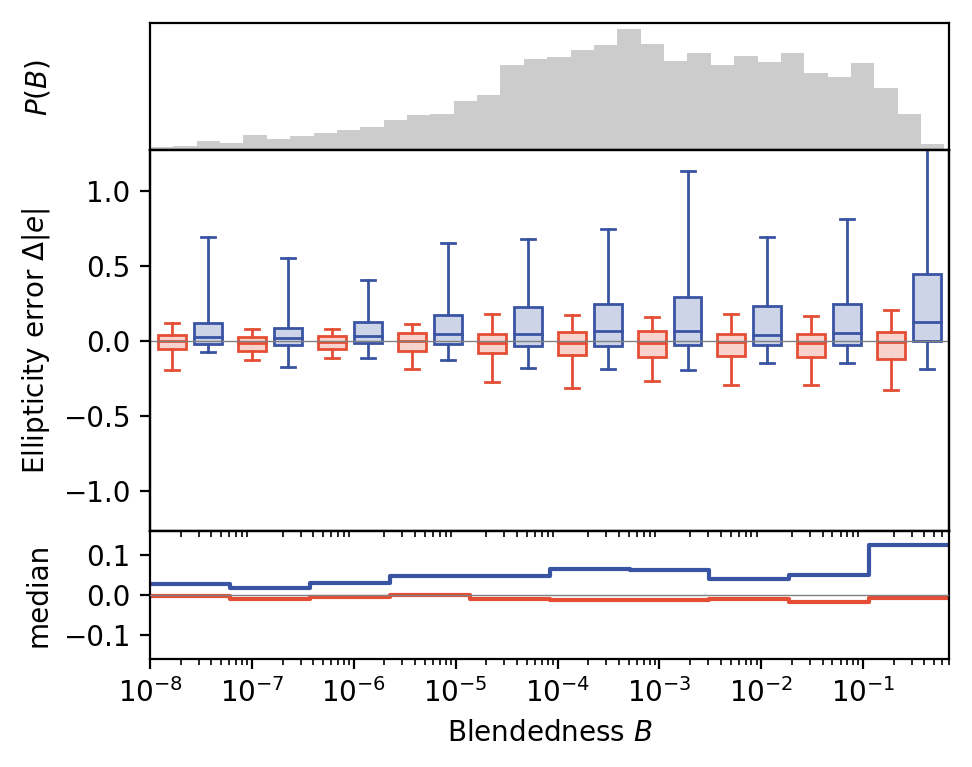

In [19]:
fig, median_shear, q1_shear, q3_shear, whislo_shear, whishi_shear = boxplot.boxplot_func(df_plot_2, x = 'blendedness', y = 'e_error_reg', z = 'exp',
              xlim = (1e-8, 0.7),
              ylim = (-1.27, 1.27),
              ylim2= (-0.158, 0.158),
              x_scale = 'log',
              legend = ['param estimation network', 'LSST pipeline'],
              x_label='Blendedness $B$', 
              y_label = 'Ellipticity error $\\Delta |e|$',
              y_label_hist='$P(B)$',
              y_label_2 = 'median',
              legend_remove = True,
              palette=mpl.cm.RdYlBu([0.15, 0.95]),
              nbins = 10)

#fig.savefig('imgs/e_blend_dc2_ell_hsm.pdf')

In [20]:
df_stat = pd.DataFrame()
df_stat['median_shear'] = np.abs(median_shear)
df_stat['q1_shear'] = np.abs(q1_shear)
df_stat['q3_shear'] = np.abs(q3_shear)
df_stat['whislo_shear'] = np.abs(whislo_shear)
df_stat['whishi_shear'] = np.abs(whishi_shear)
#df_stat['median_mag'] = np.abs(median_mag)
#df_stat['q1_mag'] = np.abs(q1_mag)
#df_stat['q3_mag'] = np.abs(q3_mag)
#df_stat['whislo_mag'] = np.abs(whislo_mag)
#df_stat['whishi_mag'] = np.abs(whishi_mag)
df_stat['stats_names'] = ['network']*10 + ['pipeline']*10

x = 10

In [21]:
df_stat

,median_shear,q1_shear,q3_shear,whislo_shear,whishi_shear,stats_names
0,0.001800,0.056724,0.037537,0.192211,0.119629,network
1,0.011122,0.066127,0.027864,0.124912,0.077951,network
2,0.006004,0.051055,0.031032,0.111040,0.076622,network
3,0.000341,0.066673,0.051188,0.185675,0.113435,network
4,0.010659,0.080069,0.042863,0.272459,0.180848,network
5,0.012525,0.092395,0.059418,0.313865,0.173589,network
6,0.012796,0.104886,0.065182,0.265869,0.157455,network
7,0.009775,0.099312,0.048755,0.294724,0.177782,network
8,0.016129,0.105188,0.046480,0.292922,0.168044,network
9,0.006409,0.118918,0.059835,0.326348,0.209208,network


In [22]:
param = 'median_shear'
print('mean for each exp: '+str([np.mean(df_stat[param][:x]), np.mean(df_stat[param][10:10+x])]))
print('improvement between each exp: '+str([np.mean(df_stat[param][10:10+x])/np.mean(df_stat[param][:+x]) ]))

mean for each exp: [0.008755958831925734, 0.051497621612620226]
improvement between each exp: [5.881437156242789]


19974
[1 2]
0 1
1 2


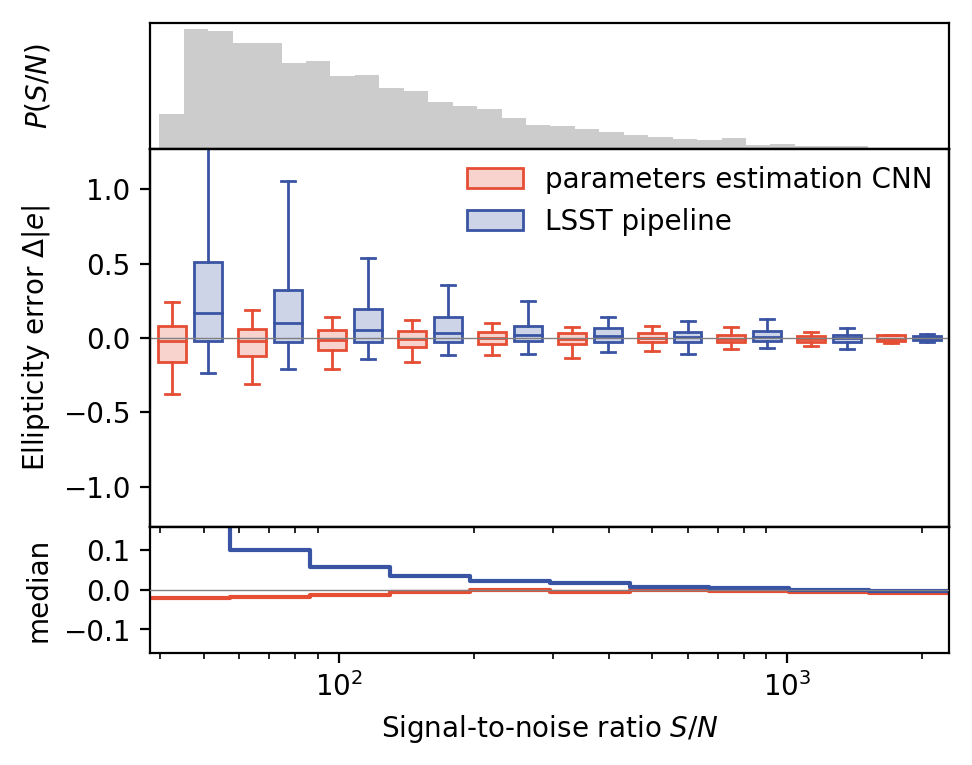

In [23]:
fig, median_shear, q1_shear, q3_shear, whislo_shear, whishi_shear = boxplot.boxplot_func(df, x = 'snr_r', y = 'e_error_reg', z = 'exp',
              xlim = (38, 2300),
              ylim = (-1.27, 1.27),
              ylim2= (-0.158, 0.158),
              x_scale = 'log',
              legend = ['parameters estimation CNN', 'LSST pipeline'],
              x_label='Signal-to-noise ratio $S/N$', 
              y_label = 'Ellipticity error $\\Delta |e|$',
              y_label_hist='$P(S/N)$',
              y_label_2 = 'median',
              legend_remove = False,
              palette=mpl.cm.RdYlBu([0.15, 0.95]),
              nbins = 10)

#fig.savefig('imgs/e_snr_dc2_ell_hsm.pdf')

In [24]:
df_stat = pd.DataFrame()
df_stat['median_shear'] = np.abs(median_shear)
df_stat['q1_shear'] = np.abs(q1_shear)
df_stat['q3_shear'] = np.abs(q3_shear)
df_stat['whislo_shear'] = np.abs(whislo_shear)
df_stat['whishi_shear'] = np.abs(whishi_shear)
#df_stat['median_mag'] = np.abs(median_mag)
#df_stat['q1_mag'] = np.abs(q1_mag)
#df_stat['q3_mag'] = np.abs(q3_mag)
#df_stat['whislo_mag'] = np.abs(whislo_mag)
#df_stat['whishi_mag'] = np.abs(whishi_mag)
df_stat['stats_names'] = ['network']*10 + ['pipeline']*10

x = 10

In [25]:
param = 'median_shear'
print('mean for each exp: '+str([np.mean(df_stat[param][:x]), np.mean(df_stat[param][10:10+x])]))
print('improvement between each exp: '+str([np.mean(df_stat[param][10:10+x])/np.mean(df_stat[param][:+x]) ]))

mean for each exp: [0.008885509484531066, 0.04118391291670724]
improvement between each exp: [4.634952333167278]


Text(0, 0.5, 'Aleatoric uncertainty $\\sigma_{al}$')

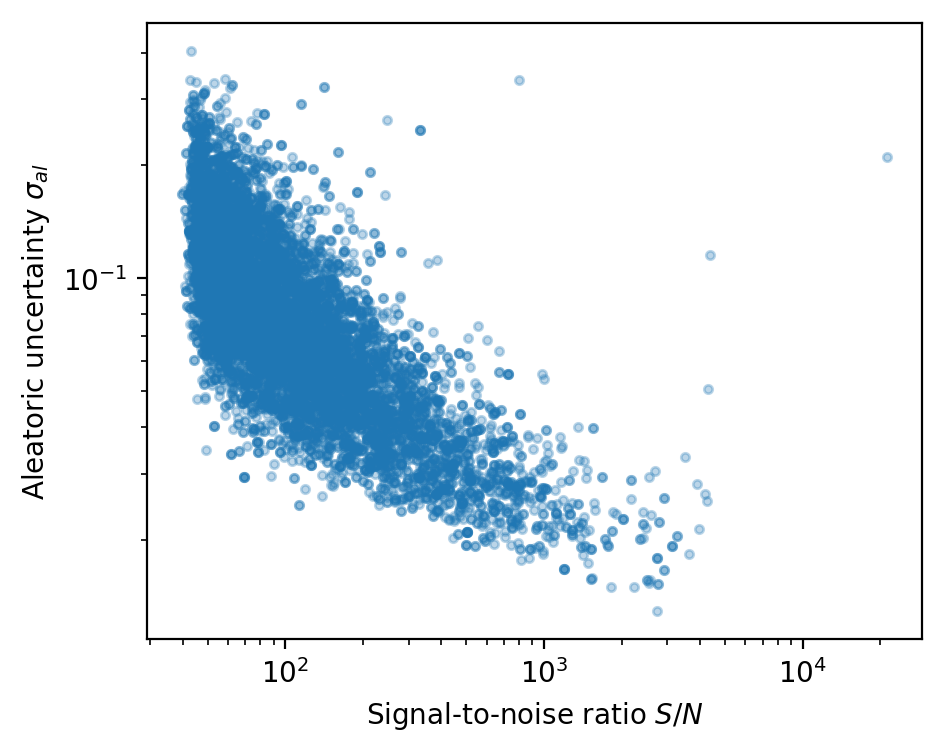

In [26]:
#plt.hist2d(data['snr_r'], d['e1_std'], bins = 10)
fig, axes = plt.subplots(1,1, figsize= (5,4))
axes.plot(data['snr_r'], d['e1_std'], '.', alpha = 0.3)
axes.set_xscale('log')
axes.set_yscale('log')

axes.set_xlabel('Signal-to-noise ratio $S/N$')
axes.set_ylabel('Aleatoric uncertainty $\sigma_{al}$')

#fig.savefig('imgs/sigma_al_param_ell.pdf')

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 10 columns):
z_in           20000 non-null float64
z_out          20000 non-null float64
e_1            19976 non-null float64
e_2            19976 non-null float64
e              19976 non-null float64
e_in           20000 non-null float64
e_error_reg    19976 non-null float64
blendedness    19998 non-null float64
snr_r          19996 non-null float64
exp            20000 non-null int64
dtypes: float64(9), int64(1)
memory usage: 1.5 MB


In [28]:
mean_error = []
std_error = []

for i, n in enumerate([1000,500,200,100,50,40,30,20,10,5,3,2]):
    mean_error_temp = []
    print(n)
    for k in range (1000):
        indices = np.random.choice(data.index, size=n, replace=False, p = None)
        mean_error_temp.append(np.mean(df['e_error_reg'][indices]))
    #print(mean_error_temp)
    mean_error.append(np.mean(mean_error_temp))
    std_error.append(np.std(mean_error_temp))

1000
500
200
100
50
40
30
20
10
5
3
2


In [29]:
np.mean(df['e_error_reg'])

0.12048077554034685

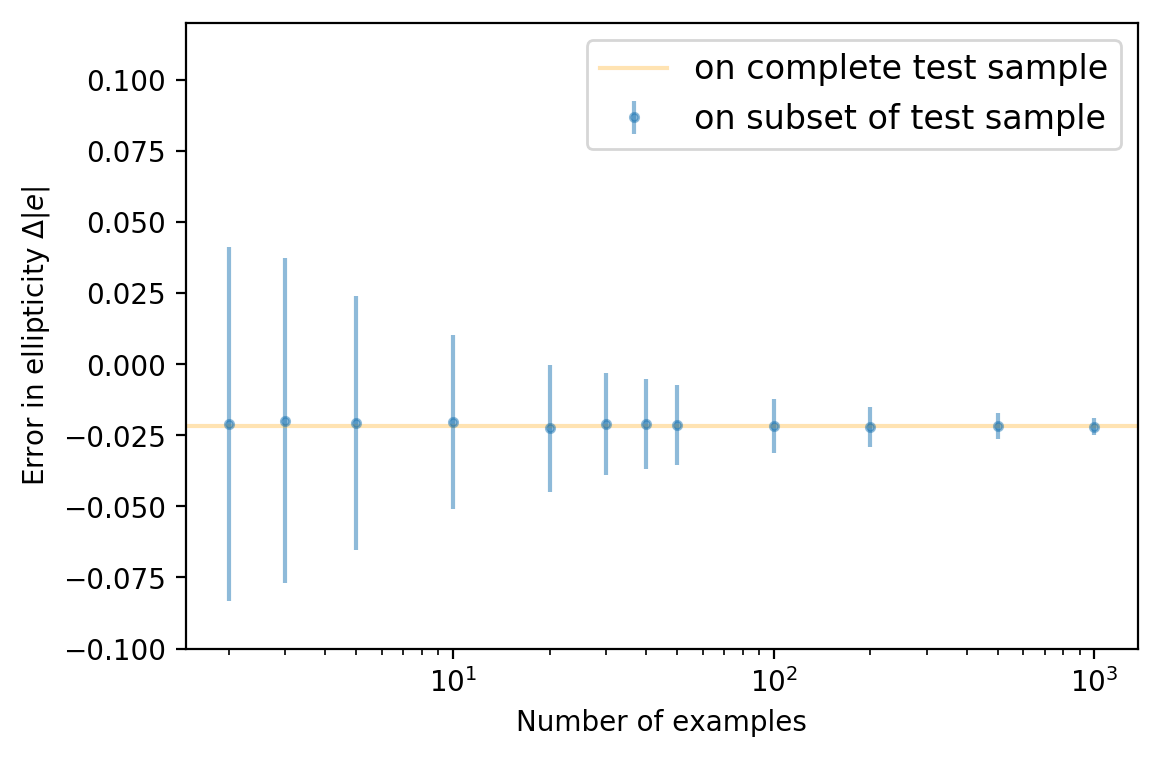

In [30]:
fig, axes = plt.subplots(1,1, figsize =(6,4))
font = {'family' : 'normal',
        'size'   : 12}

matplotlib.rc('font', **font)

axes.errorbar(np.array([1000,500,200,100,50,40,30,20,10,5,3,2]),np.array(mean_error),yerr=np.array(std_error), fmt='.', label = 'on subset of test sample', alpha = 0.5)
axes.set_xscale('log')
axes.set_xlabel('Number of examples')
axes.set_ylabel('Error in ellipticity $\Delta |e|$')
axes.set_ylim(-0.1,0.12)
axes.axhline(np.mean(df['e_error_reg'][:10000]), color = 'orange', alpha = 0.3, label = 'on complete test sample')
axes.legend()
plt.tight_layout()

#fig.savefig('imgs/error_on_subsample.pdf')

### Redshift

In [31]:
df = pd.DataFrame()

d = pd.DataFrame()
d['e1'] = df_plot['e1_out_mean']
d['e2'] = df_plot['e2_out_mean']
d['e1_std'] = df_plot['e1_out_std']
d['e2_std'] = df_plot['e2_out_std']
d['e1_in'] = -e1
d['e2_in'] = e2
d['e_in'] = np.sqrt(d['e1_in']**2+d['e2_in']**2)

df['z_in']= data['redshift']
df['z_out']= df_plot['z_out_mean']
df['z_error'] = df['z_out']-df['z_in']

#df['e_1'] = pd.concat([d['e1'],data['e1_hsm_regauss']], ignore_index = True)#, ignore_index=True, sort = True)
#df['e_2'] = pd.concat([d['e2'],data['e2_hsm_regauss']], ignore_index = True)
#df['e'] = pd.concat([np.sqrt(d['e1']**2+d['e2']**2),np.sqrt(data['e1_hsm_regauss']**2+data['e2_hsm_regauss']**2)], ignore_index = True)
#df['e_in'] = pd.concat([d['e_in'],d['e_in']], ignore_index = True)
#df['e_error_reg'] = df['e']-df['e_in']
#df['e_1_hsm'] = data['e1_hsm_regauss'][indices]
#df['e_2_hsm'] = data['e2_hsm_regauss'][indices]
#df['e_hsm'] = np.sqrt(df['e_1_hsm']**2+df['e_2_hsm']**2)

df['blendedness'] = data['blendedness']
df['snr_r'] = data['snr_r']

df['exp'] = [1]*10000

In [32]:
df_plot_2 = df[df['blendedness']>0]

8095
[1]
0 1


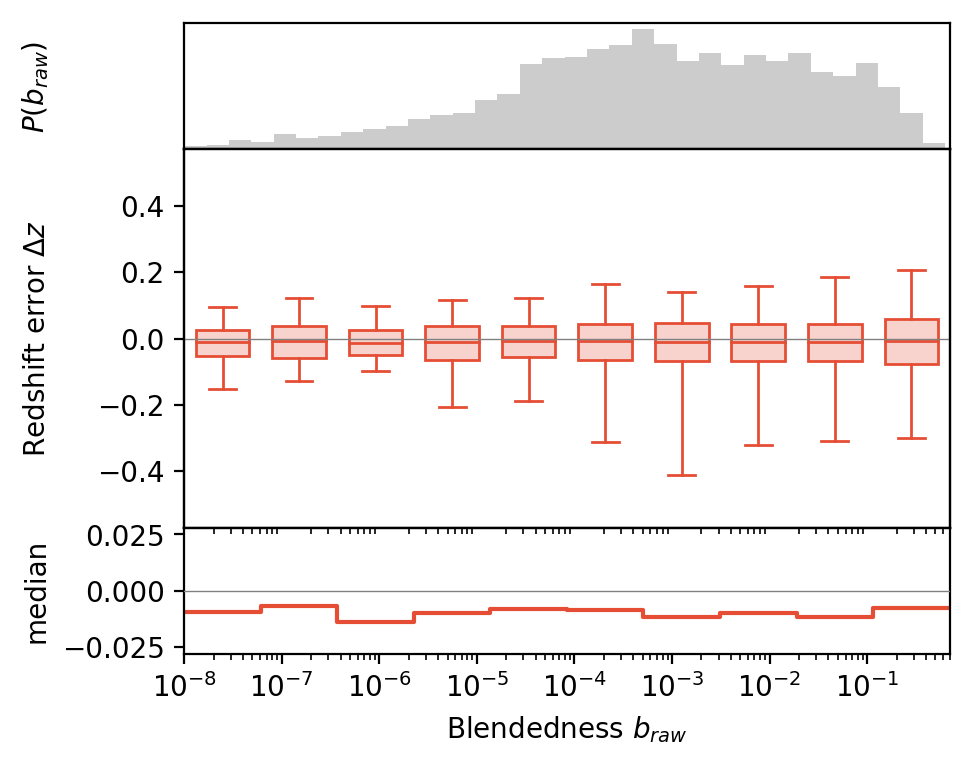

In [45]:
fig, median_shear, q1_shear, q3_shear, whislo_shear, whishi_shear = boxplot.boxplot_func(df_plot_2, x = 'blendedness', y = 'z_error', z = 'exp',
              xlim = (1e-8, 0.7),
              ylim = (-0.57,0.57), 
              ylim2 = (-0.028,0.028), 
              x_scale = 'log',
              legend = ['Deblender with VAE'],
              x_label='Blendedness $b_{raw}$', 
              y_label = 'Redshift error $\\Delta z$',
              y_label_hist='$P(b_{raw})$',
              y_label_2 = 'median',
              legend_remove = True,
              palette=mpl.cm.RdYlBu([0.15]),
              nbins = 10)
fig.savefig('imgs/z_blend_dc2_no_psf.pdf')

8095
[1]
0 1


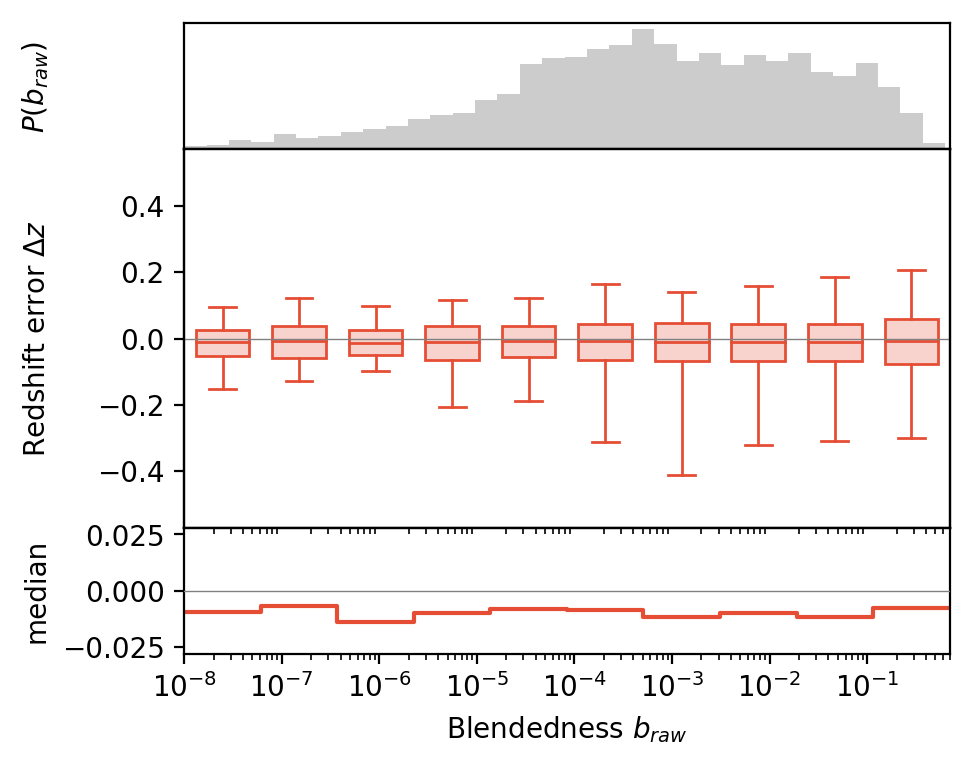

In [34]:
fig, median_shear, q1_shear, q3_shear, whislo_shear, whishi_shear = boxplot.boxplot_func(df_plot_2, x = 'blendedness', y = 'z_error', z = 'exp',
              xlim = (1e-8, 0.7),
              ylim = (-0.57,0.57), 
              ylim2 = (-0.028,0.028), 
              x_scale = 'log',
              legend = ['Deblender with VAE'],
              x_label='Blendedness $b_{raw}$', 
              y_label = 'Redshift error $\\Delta z$',
              y_label_hist='$P(b_{raw})$',
              y_label_2 = 'median',
              legend_remove = True,
              palette=mpl.cm.RdYlBu([0.15]),
              nbins = 10)

#fig.savefig('imgs/z_blend_dc2_no_psf.pdf')

8095
[1]
0 1


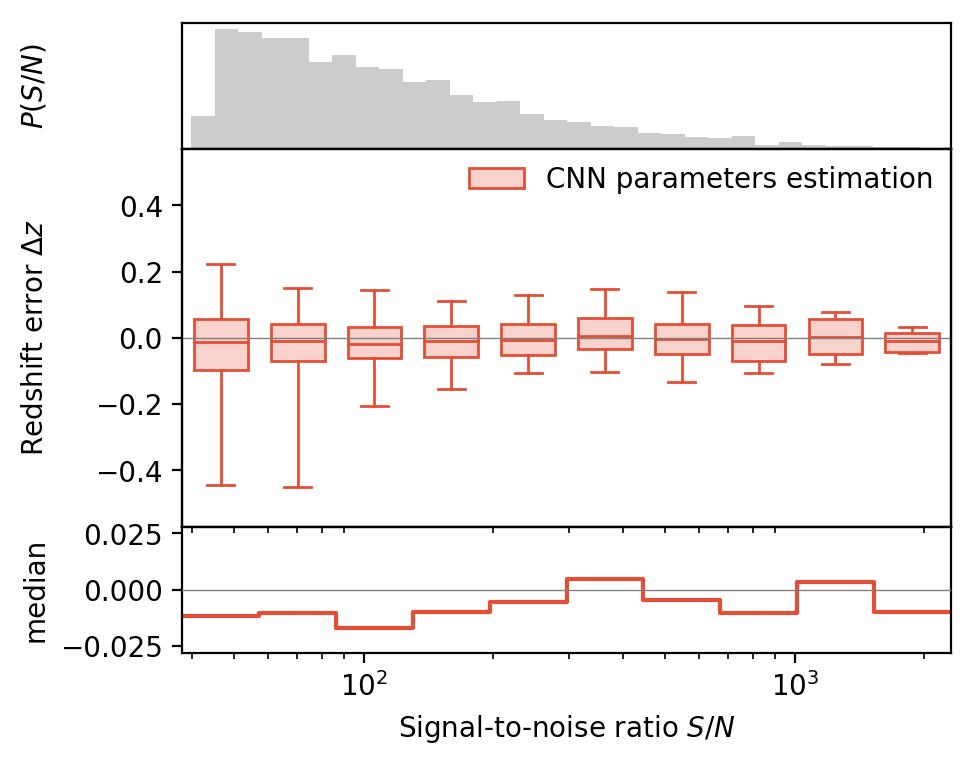

In [48]:
fig, median_shear, q1_shear, q3_shear, whislo_shear, whishi_shear = boxplot.boxplot_func(df_plot_2, x = 'snr_r', y = 'z_error', z = 'exp',
              xlim = (38, 2300),
              ylim = (-0.57,0.57), 
              ylim2 = (-0.028,0.028), 
              x_scale = 'log',
              legend = ['CNN parameters estimation'],
              x_label='Signal-to-noise ratio $S/N$', 
              y_label = 'Redshift error $\\Delta z$',
              y_label_hist='$P(S/N)$',
              y_label_2 = 'median',
              legend_remove = False,
              palette=mpl.cm.RdYlBu([0.15]),
              nbins = 10)

fig.savefig('imgs/z_snr_dc2_no_psf.pdf')

8095
[1]
0 1


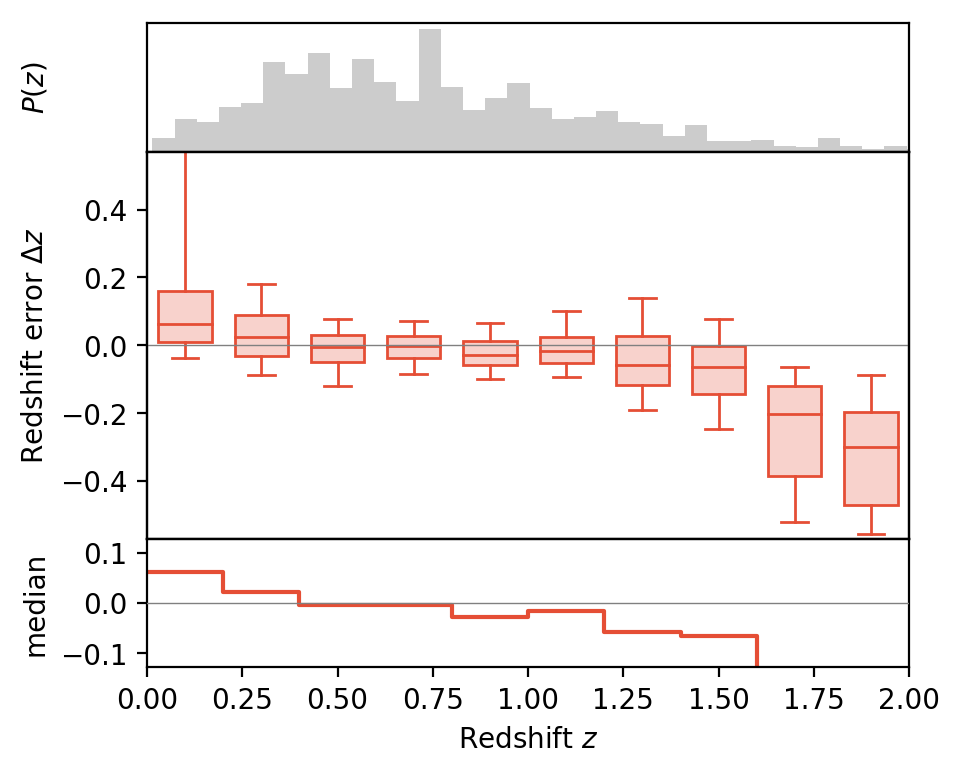

In [51]:
fig, median_shear, q1_shear, q3_shear, whislo_shear, whishi_shear = boxplot.boxplot_func(df_plot_2, x = 'z_in', y = 'z_error', z = 'exp',
              xlim = (0, 2),
              ylim = (-0.57,0.57), 
              ylim2 = (-0.128,0.128), 
              x_scale = 'linear',
              legend = ['Deblender with VAE'],
              x_label='Redshift $z$', 
              y_label = 'Redshift error $\\Delta z$',
              y_label_hist='$P(z)$',
              y_label_2 = 'median',
              legend_remove = True,
              palette=mpl.cm.RdYlBu([0.15]),
              nbins = 10)
fig.savefig('imgs/z_z_dc2_no_psf.pdf')

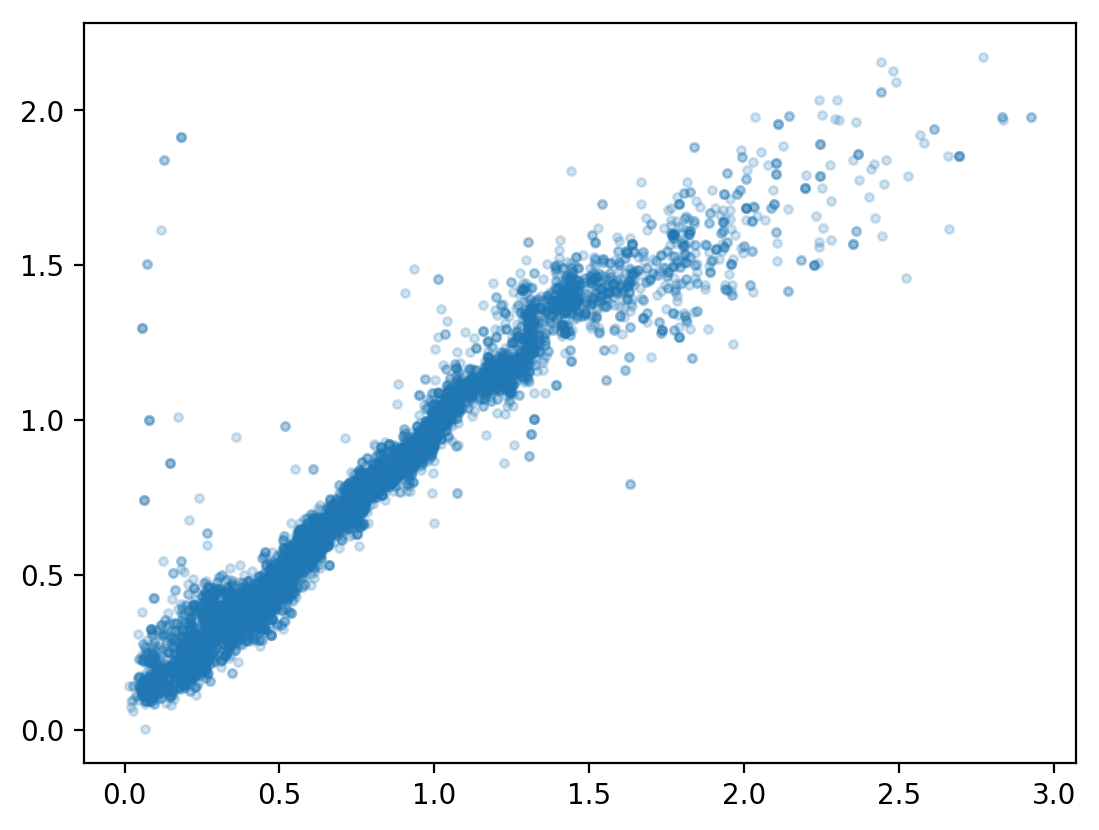

In [36]:
plt.plot(data['redshift'], df_plot['z_out_mean'], '.', alpha = 0.2)

Text(0, 0.5, '$\\sigma_z$')

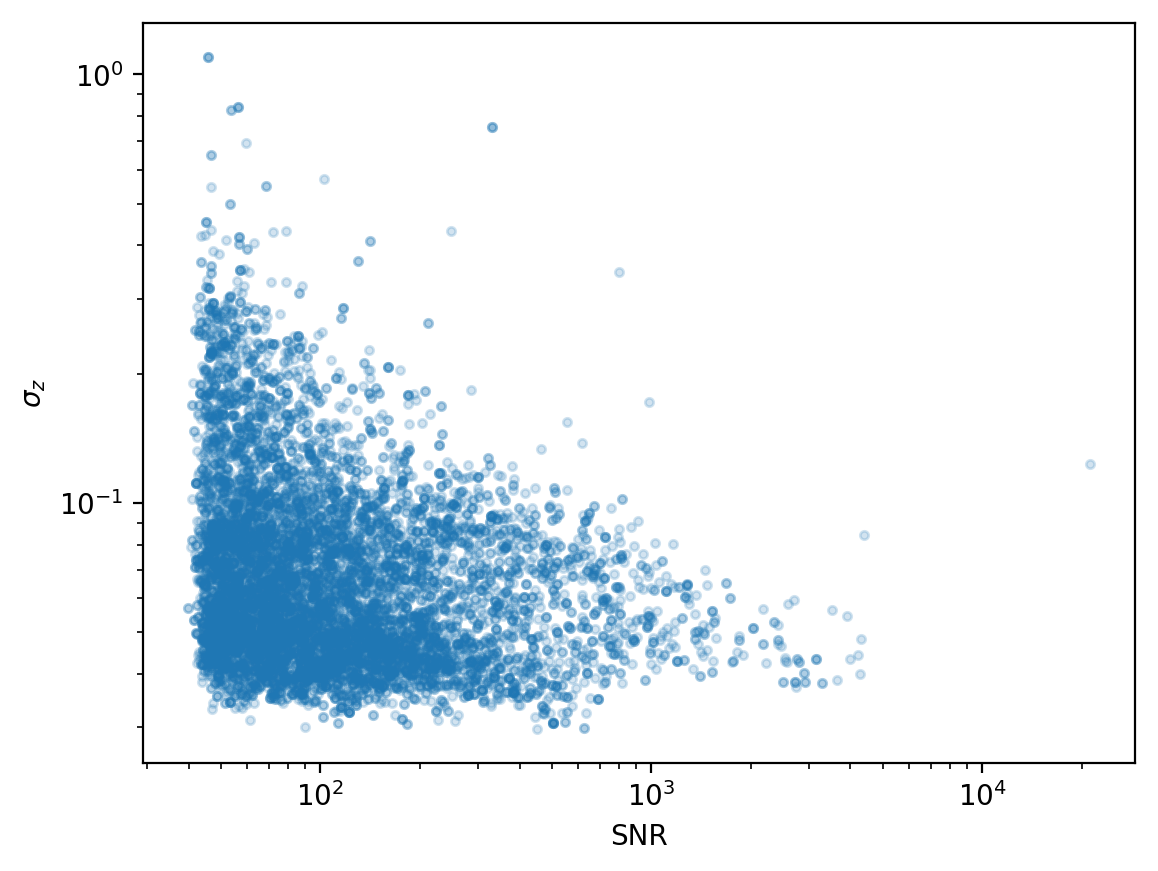

In [37]:
plt.plot(data['snr_r'], df_plot['z_out_std'], '.', alpha = 0.2)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('SNR')
plt.ylabel('$\sigma_z$')

Text(0, 0.5, '$\\sigma_z$')

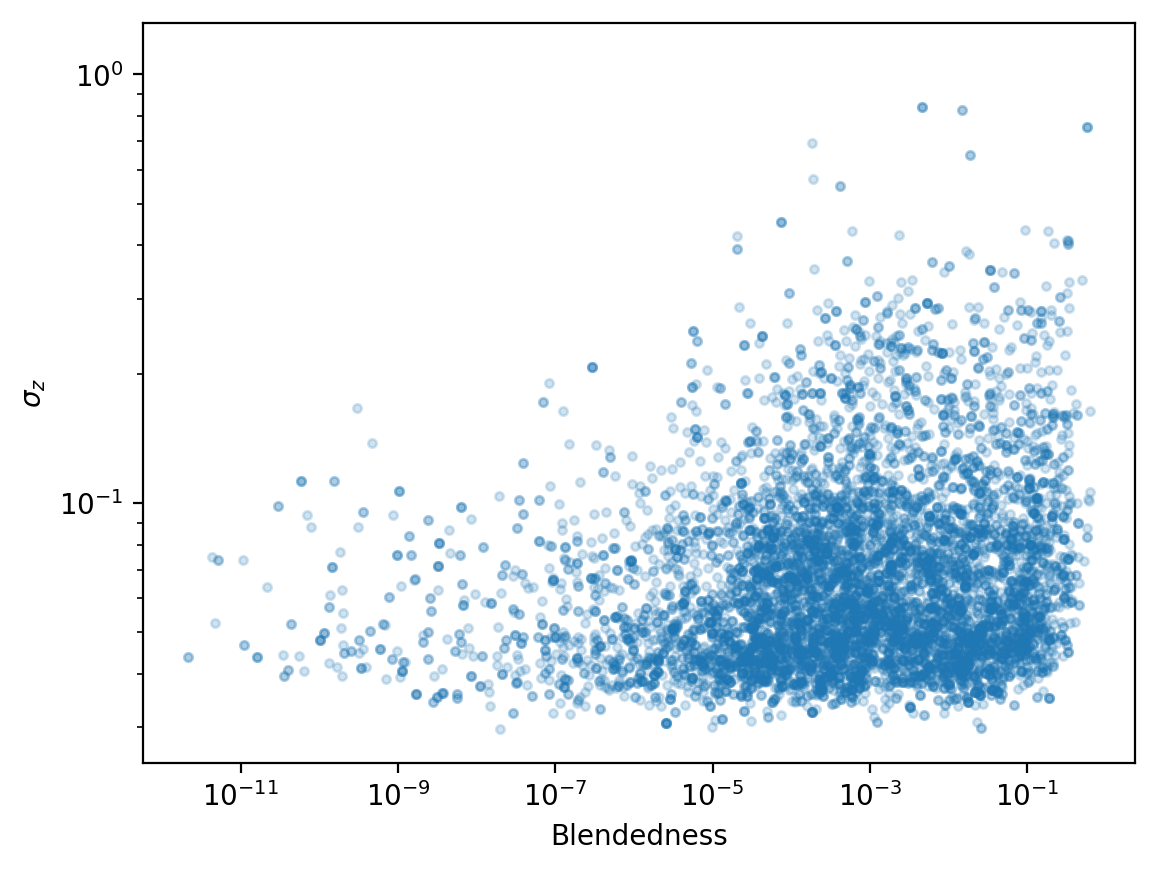

In [38]:
plt.plot(data['blendedness'], df_plot['z_out_std'], '.', alpha = 0.2)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Blendedness')
plt.ylabel('$\sigma_z$')

Text(0, 0.5, '$\\sigma_z$')

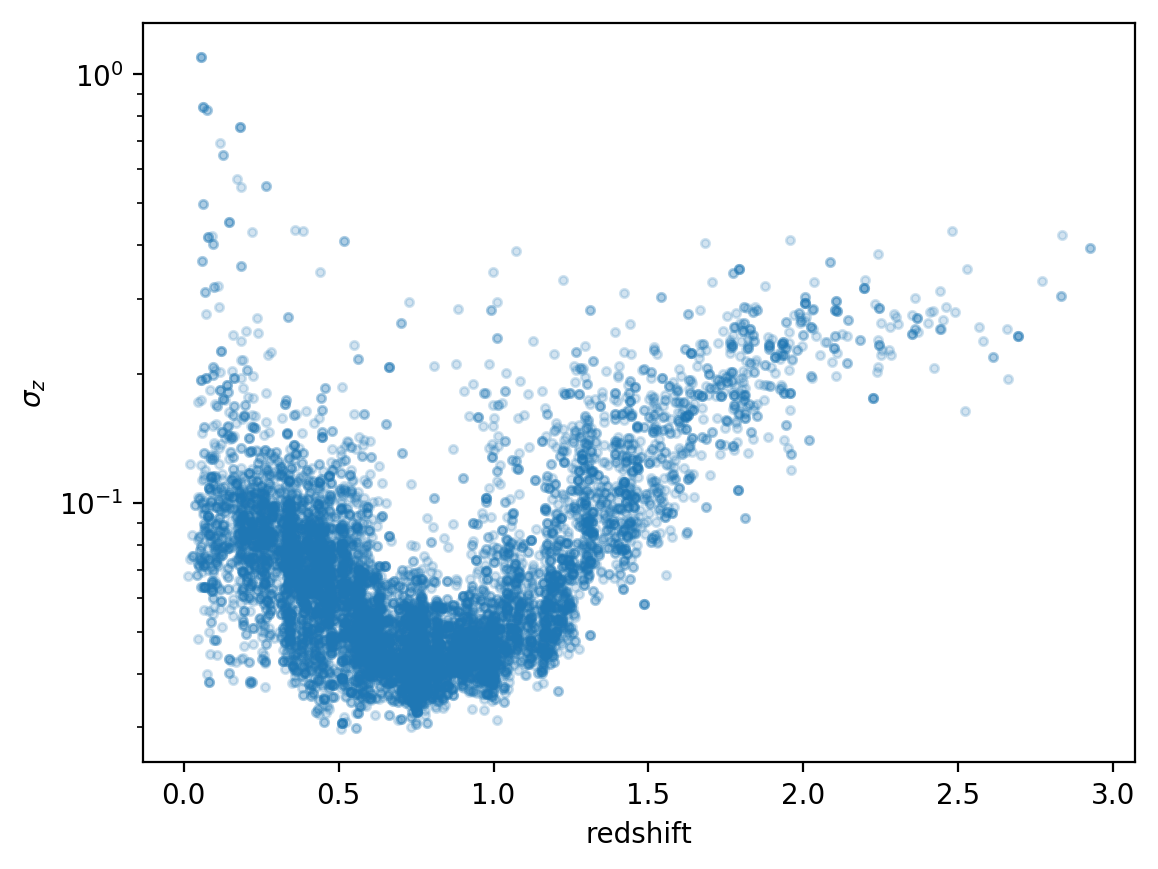

In [39]:
plt.plot(data['redshift'], df_plot['z_out_std'], '.', alpha = 0.2)
plt.xscale('linear')
plt.yscale('log')
plt.xlabel('redshift')
plt.ylabel('$\sigma_z$')

## Bayesian neural network

### Perform test

In [ ]:
output_v1 = model_det([tf.cast(images[0:3000], tf.float32), tf.cast(psf[0:3000], tf.float32)])

mean = K.get_value(output_v1.mean())
std = K.get_value(output_v1.stddev())

e1_out_mean = mean[:,0]
e2_out_mean = mean[:,1]

e1_out_std = std[:,0]
e2_out_std = std[:,1]

In [ ]:
df = pd.DataFrame()

df['e1_out_mean'] = e1_out_mean
df['e2_out_mean'] = e2_out_mean
df['e1_out_std'] = e1_out_std
df['e2_out_std'] = e2_out_std

df.to_csv('data/df_param_ell_bnn_1.csv')

In [ ]:
part_1 = pd.read_csv('data/df_param_ell_bnn_1.csv', encoding = 'utf-8')
part_2 = pd.read_csv('data/df_param_ell_bnn_2.csv', encoding = 'utf-8')
part_3 = pd.read_csv('data/df_param_ell_bnn_3.csv', encoding = 'utf-8')
part_4 = pd.read_csv('data/df_param_ell_bnn_4.csv', encoding = 'utf-8')

df_plot_bnn = pd.concat([part_1,part_2, part_3, part_4], ignore_index = True)

### Plots specifiques BNN

# Comparison BNN, Det, LSST pipeline

In [ ]:
df_no_psf = pd.read_csv('data/df_vae_dc2_no_psf_noisy_i.csv', encoding = 'utf-8')

In [ ]:
part_1 = pd.read_csv('data/df_param_ell_1.csv', encoding = 'utf-8')
part_2 = pd.read_csv('data/df_param_ell_2.csv', encoding = 'utf-8')
part_3 = pd.read_csv('data/df_param_ell_3.csv', encoding = 'utf-8')
part_4 = pd.read_csv('data/df_param_ell_4.csv', encoding = 'utf-8')

df_plot_det = pd.concat([part_1,part_2, part_3, part_4], ignore_index = True)

part_1 = pd.read_csv('data/df_param_ell_bnn_1.csv', encoding = 'utf-8')
part_2 = pd.read_csv('data/df_param_ell_bnn_2.csv', encoding = 'utf-8')
part_3 = pd.read_csv('data/df_param_ell_bnn_3.csv', encoding = 'utf-8')
part_4 = pd.read_csv('data/df_param_ell_bnn_4.csv', encoding = 'utf-8')

df_plot_bnn = pd.concat([part_1,part_2, part_3, part_4], ignore_index = True)

In [ ]:
df = pd.DataFrame()

d = pd.DataFrame()
d['e1_det'] = df_plot_det['e1_out_mean']
d['e2_det'] = df_plot_det['e2_out_mean']
d['e1_std_det'] = df_plot_det['e1_out_std']
d['e2_std_det'] = df_plot_det['e2_out_std']
d['e1_bnn'] = df_plot_no_bnn['e1_out_mean']
d['e2_bnn'] = df_plot_no_bnn['e2_out_mean']
d['e1_std_bnn'] = df_plot_no_bnn['e1_out_std']
d['e2_std_bnn'] = df_plot_no_bnn['e2_out_std']
d['e1_in'] = -e1
d['e2_in'] = e2
d['e_in'] = np.sqrt(d['e1_in']**2+d['e2_in']**2)

df['e_1'] = pd.concat([d['e1_det'],df_no_psf['e1_hsm_regauss'],d['e1_bnn']], ignore_index = True)
df['e_2'] = pd.concat([d['e2_det'],df_no_psf['e2_hsm_regauss'],d['e2_bnn']], ignore_index = True)
df['e'] = pd.concat([np.sqrt(d['e1_det']**2+d['e2_det']**2),np.sqrt(df_no_psf['e1_hsm_regauss']**2+df_no_psf['e2_hsm_regauss']**2),np.sqrt(d['e1_bnn']**2+d['e2_bnn']**2)], ignore_index = True)
df['e_in'] = pd.concat([d['e_in'],d['e_in'],d['e_in']], ignore_index = True)
df['e_error_reg'] = df['e']-df['e_in']

df['blendedness'] = pd.concat([data['blendedness'],data['blendedness'],data['blendedness']], ignore_index = True)
df['snr_r'] = pd.concat([data['snr_r'],data['snr_r'],data['snr_r']], ignore_index = True)

df['exp'] = [1]*10000+[2]*10000+[3]*10000

In [ ]:
df_plot_2 = df[df['blendedness']>0]

In [ ]:
fig, median_shear, q1_shear, q3_shear, whislo_shear, whishi_shear = boxplot.boxplot_func(df_plot_2, x = 'blendedness', y = 'e_error_reg', z = 'exp',
              xlim = (1e-8, 0.7),
              ylim = (-1.27, 1.27),
              ylim2= (-0.158, 0.158),
              x_scale = 'log',
              legend = ['CNN parameters estimation', 'DebVAder', 'BNN parameters estimation'],
              x_label='Blendedness $B$', 
              y_label = 'Ellipticity error $\\Delta |e|$',
              y_label_hist='$P(B)$',
              y_label_2 = 'median',
              legend_remove = True,
              palette=mpl.cm.RdYlBu([0.15,0.35, 0.95]),
              nbins = 10)

#fig.savefig('imgs/e_blend_dc2_from_vae_hsm.pdf')

In [ ]:
fig, median_shear, q1_shear, q3_shear, whislo_shear, whishi_shear = boxplot.boxplot_func(df_plot_2, x = 'snr_r', y = 'e_error_reg', z = 'exp',
              xlim = (38, 2300),
              ylim = (-1.27, 1.27),
              ylim2= (-0.158, 0.158),
              x_scale = 'log',
              legend = ['CNN parameters estimation', 'DebVAder', 'BNN parameters estimation'],
              x_label='Signal-to-noise ratio $S/N$', 
              y_label = 'Ellipticity error $\\Delta |e|$',
              y_label_hist='$P(S/N)$',
              y_label_2 = 'median',
              legend_remove = True,
              palette=mpl.cm.RdYlBu([0.15,0.35, 0.95]),
              nbins = 10)